<a href="https://colab.research.google.com/github/PreciousAkpokighe/AI-ML-Training-course-professional-programme-with-Imperial-College-London/blob/main/Self_study_try_it_activity_14_2__Training_models_using_different_kernels_on_two_dimensional_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-study try-it activity 14.2: Training models using different kernels on two-dimensional data

Training SVM models with different kernels is necessary because each kernel enables the SVM to capture different types of relationships in the data – linear kernels are used for linearly separable data, and non-linear kernels (such as RBF or polynomial) are used for more complex patterns. Testing multiple kernels helps find the one that best fits the underlying structure of the two-dimensional data, improving classification accuracy.

In this notebook, the data is trained on different kernels, and the best-performing model is selected based on performance.



In [1]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#Use the following to plot SVMs
from mlxtend.plotting import plot_decision_regions #On terminal, install pip.install mlxtend

#### Task 1: SVM-based classifier on a non-separable data set
**Load the two-dimensional data `Case3rings/X.npy` that has 150 rows and two columns and the corresponding target `Case3rings/y.np.`**

In [3]:
X = np.load('X.npy')
y = np.load('y.npy')

**Plot the two-dimensional points and colour them so that points with the same class have the same colour**

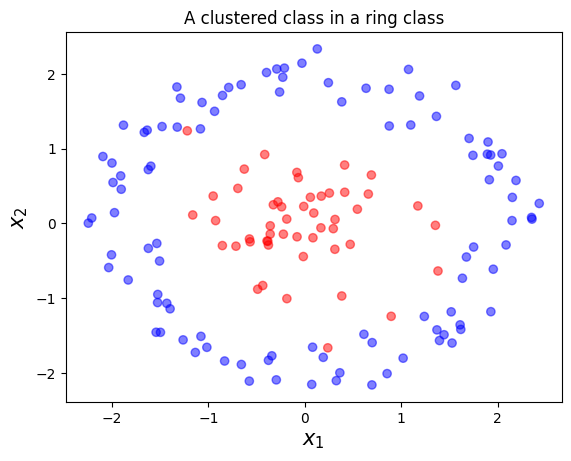

In [4]:
n = 100
color = np.concatenate((np.repeat("blue", n), np.repeat("red",n/2)), axis=0)
plt.scatter(X[:,0], X[:,1], c = color, alpha= .5)
plt.xlabel("$x_1$", size = 15)
plt.ylabel("$x_2$", size = 15)
plt.title("A clustered class in a ring class")
plt.show()

**Does a linear SVM-based classifier (SVC) sound like a good idea? First, discuss your opinion, then demonstrate it by training, showing the confusion matrix and plotting the boundary.**

- Answer: Linear SVM yields a single straight boundary; concentric rings are not linearly separable, so the model collapses to the majority class.

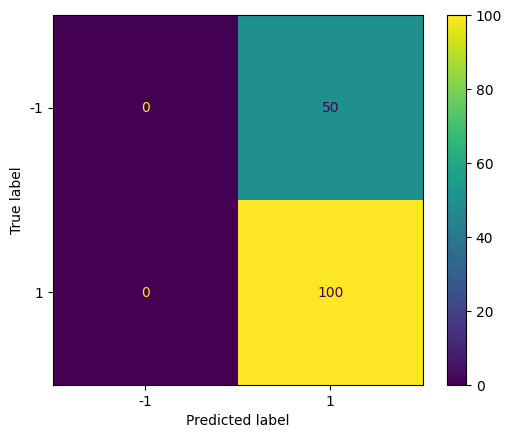

In [5]:
clf = svm.SVC(kernel = 'linear')
clf.fit(X, y);
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot(); #You see that this model never predicts -1

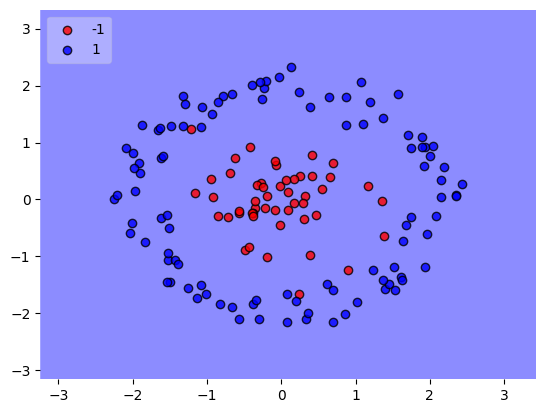

In [6]:
import warnings
with warnings.catch_warnings(): #Otherwise the package might complain there is no "boundary" as we classify all as '1'
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o");
    ax=plt.gca();
    plt.show();

## Question 1:
**In the linear SVC case above, why did your model end up classifying every instance with the same prediction?**

## Answer:
A linear SVM kernel can only create a straight-line decision boundary, which cannot separate non-linear data such as two concentric rings. As a result, the model fails to distinguish between the rings and often assigns all instances to the same class, leading to poor accuracy and trivial predictions.

In [7]:
pd.Series(y.ravel()).value_counts()


,count
1,100
-1,50


## Question 2:

**Try a radial kernel instead (with default parameters) and then report the performance and plot the decision boundary.**

Notes:
- To change the kernel, try, e.g. `kernel = 'rbf.'`
- To change the cost, try, e.g. `C = 10.`
- To change the scale parameter of the RBF, try, e.g. `gamma = 4.`
- See more options in the [official documentation.](https://scikit-learn.org/stable/modules/svm.html)

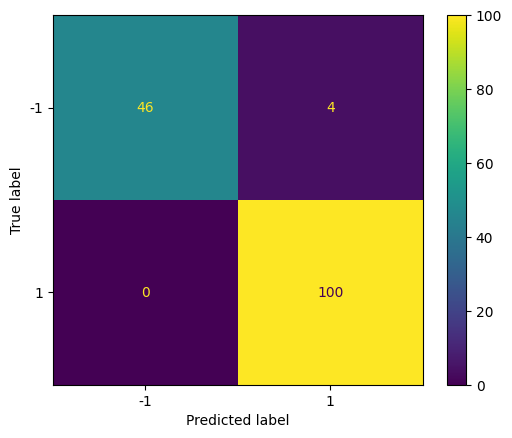

In [8]:
clf = svm.SVC(kernel = 'rbf')
clf.fit(X, y);
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

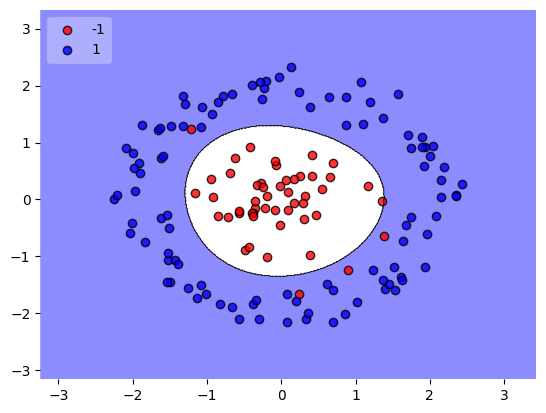

In [9]:
plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o");
ax=plt.gca();
plt.show();

**Try a radial kernel (or RBF) with gamma = 10.` Interpret the decision boundary.**

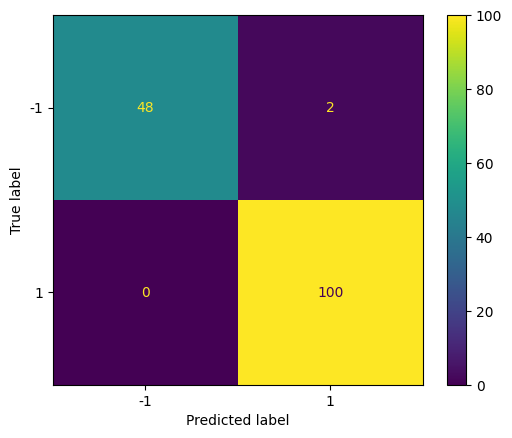

In [10]:
clf = svm.SVC(kernel = 'rbf', gamma = 10)
clf.fit(X, y);
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

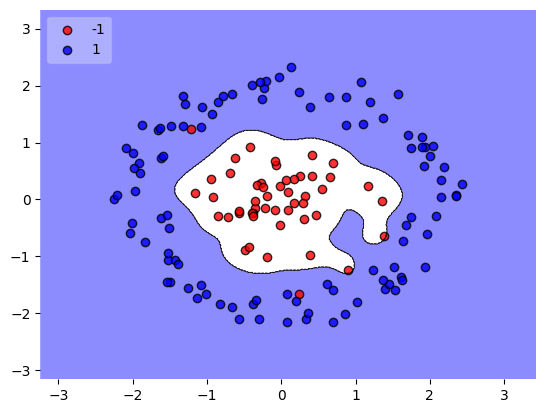

In [11]:
plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o");
ax=plt.gca();
plt.show();

## Answer:
You can see that the shape of the RBF looks less like a circle and starts to obtain 'tentacles'. :)

## Question 3:
**Apply the same steps for a polynomial kernel with degree 3.**

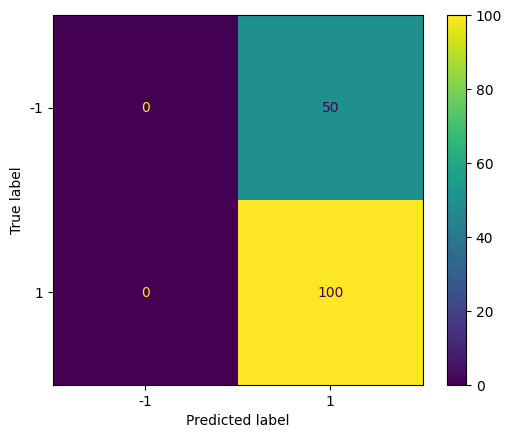

In [12]:
clf = svm.SVC(kernel = 'poly', degree = 3)
clf.fit(X, y);
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

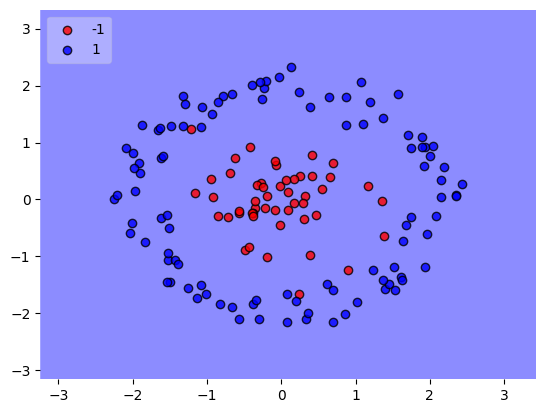

In [13]:
with warnings.catch_warnings(): #Otherwise the package might complain there is no "boundary" as we classify all as '1'
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o");
    ax=plt.gca();
    plt.show();

**Now try a polynomial Kernel with degree 8 and cost 1.**

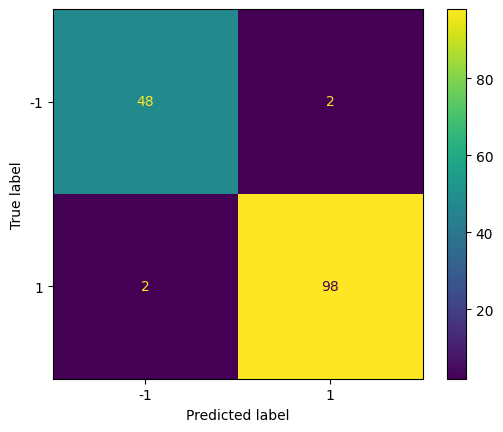

In [14]:
clf = svm.SVC(kernel = 'poly', degree = 8, C = 1)
clf.fit(X, y);
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

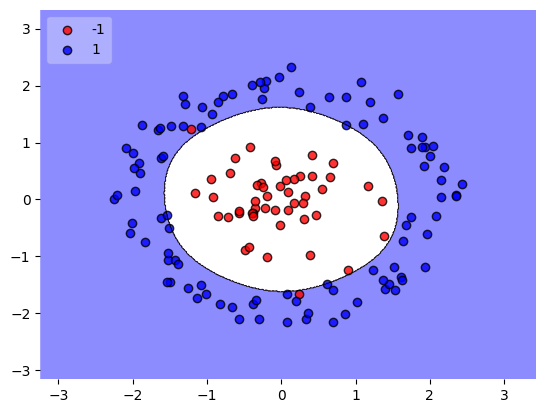

In [15]:
with warnings.catch_warnings(): #Otherwise the package might complain there is no "boundary" as we classify all as '1'
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o");
    ax=plt.gca();
    plt.show();

**Change the cost in the above case to 10.**

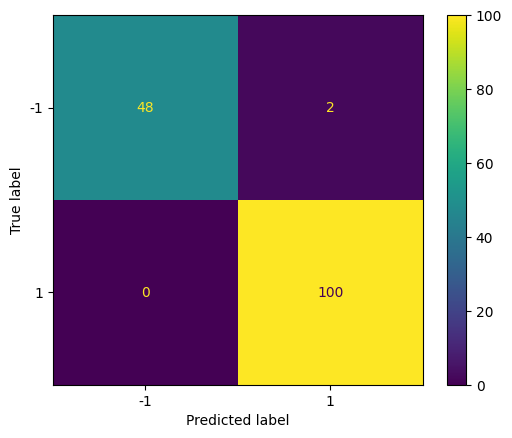

In [16]:
clf = svm.SVC(kernel = 'poly', degree = 8, C = 10)
clf.fit(X, y);
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

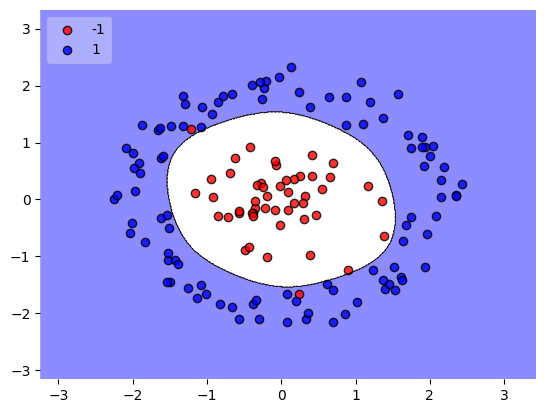

In [17]:
with warnings.catch_warnings(): #Otherwise the package might complain there is no "boundary" as we classify all as '1'
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o");
    ax=plt.gca();
    plt.show();

##### Notes:
- As you may have realized, the selection of a Kernel is not straightforward.
- The best-performing kernels in this example are the polynomial with degree 8 and cost 10 and the RBF with gamma 10.
- Even if you correctly guess the RBF with gamma 10 but use a different cost, your results may get significantly worse.

## Question 4:
To illustrate the final point, do the following:
- Run a radial kernel SVM with gamma 10 but use a cost 0.3.
- Run a sigmoid kernel and analyse the outputs of both.

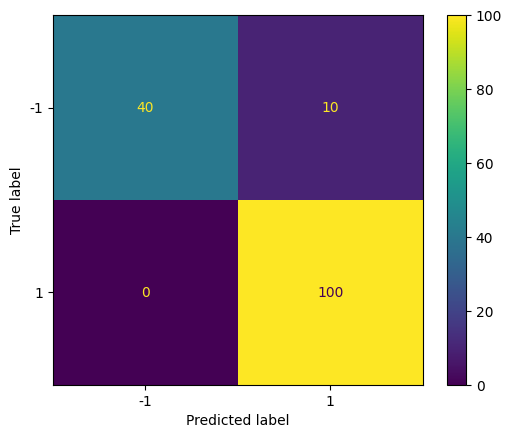

In [18]:
clf = svm.SVC(kernel = 'rbf', gamma = 10, C = 0.3)
clf.fit(X, y);
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

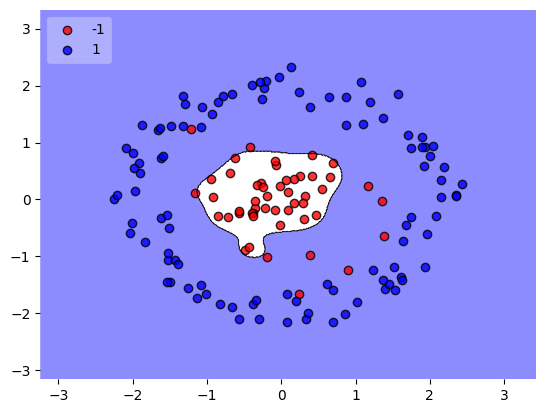

In [19]:
with warnings.catch_warnings(): #Otherwise the package might complain there is no "boundary" as we classify all as '1'
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o");
    ax=plt.gca();
    plt.show();

**Now, use a sigmoid kernel, display the confusion matrix and plot the decision boundary. Does the sigmoid kernel look like a good match here?**

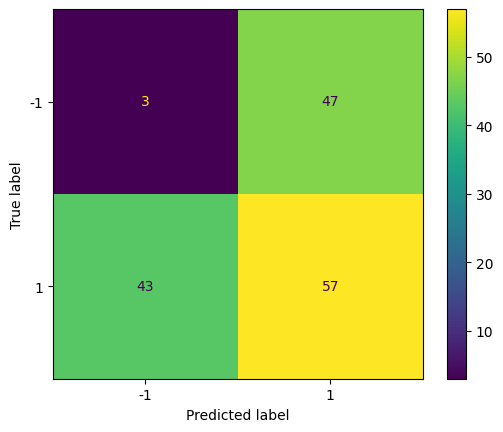

In [20]:
clf = svm.SVC(kernel = 'sigmoid')
clf.fit(X, y);
cm = confusion_matrix(y, clf.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

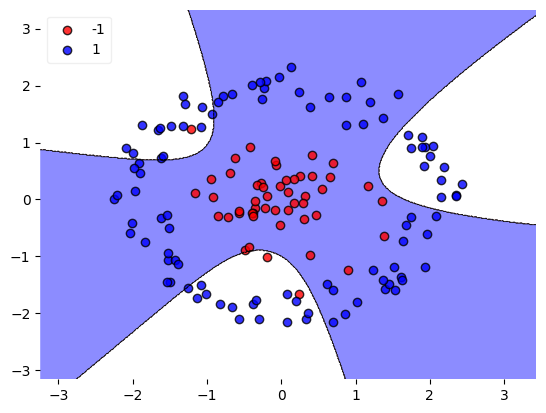

In [21]:
with warnings.catch_warnings(): #Otherwise the package might complain there is no "boundary" as we classify all as '1'
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf, legend=2, colors = "red,blue", markers= "o");
    ax=plt.gca();
    plt.show();

## Answer:
This data does not look like a good match for a sigmoid Kernel.

## Question 5:
**Assume that you will select one of the models you trained above. You compare the accuracy of each model and select the best-performing one. Are you over- or underestimating the error of the selected model? Why? If this is a problem, propose a way to fix it.**

## Answer:
Parameter selection must be done carefully. In large projects, trying every possible setting and comparing them manually is not practical. Comparing results only on the training set favours models that overfit – for example, a high-degree polynomial may appear better than a lower-degree one, but this underestimates the true error. Using the test set for model choice also underestimates the error because it is no longer an independent evaluation. The proper approach is to evaluate models on a separate validation set or to use cross-validation, reserving the test set strictly for the final assessment.